# Lesson 01 · The beta distribution

**Source:** *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 2 (pp. 12–19)

**Question:** A batter's first at-bat is a hit, so his average is 1.000. Why should that barely change what we believe about him, and how do we put that belief into numbers?

**Goal:** Use the beta distribution as a distribution *of probabilities*, update it with hits and misses, and check by simulation that the update rule really is Bayes' theorem.

**Contents**

1. The beta distribution's shapes
2. A prior for batting averages
3. Updating: prior + evidence = posterior
4. Why the update works: simulating ten million players
5. Exercises (including a card-pack version)

**Tags:** `beta-distribution` `binomial` `prior` `posterior` `conjugate-prior` `simulation`

**Before you start:** No data needed. Read Chapter 2 of the book first, or alongside.

*How this notebook works:* each **Your turn** prompt is followed by an empty cell for your code. **Check** boxes give values to compare against; they come from the book, and your numbers can differ slightly because the Lahman data now runs through more recent seasons. **Reflect** prompts are for short written answers. Every prompt is numbered *lesson.section.question* (for example **2.3.1**), so you can refer to it; empty code cells and answer cells carry the same number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats, optimize, special

import eb_data   # helpers in this folder: loading the Lahman data, saving results

rng = np.random.default_rng(2017)
pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (7, 4)
print(f"numpy {np.__version__} | pandas {pd.__version__} | scipy {scipy.__version__}")

numpy 2.5.3 | pandas 3.0.6 | scipy 1.18.1


## 1. The beta distribution's shapes

The beta distribution lives on the interval (0, 1), so each value it produces can be read as a probability. It has two shape parameters, $\alpha$ and $\beta$:

$$\text{mean} = \frac{\alpha}{\alpha+\beta}, \qquad \text{variance} = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}.$$

A handy way to think about it: $\alpha$ counts "successes", $\beta$ counts "failures", and $\alpha+\beta$ says how much evidence the curve represents.

**1.1.1 · Your turn.** Plot the densities of Beta(1, 2), Beta(3, 3), Beta(20, 20) and Beta(50, 10) on one chart over (0, 1). Use `stats.beta(a, b).pdf(x)`.

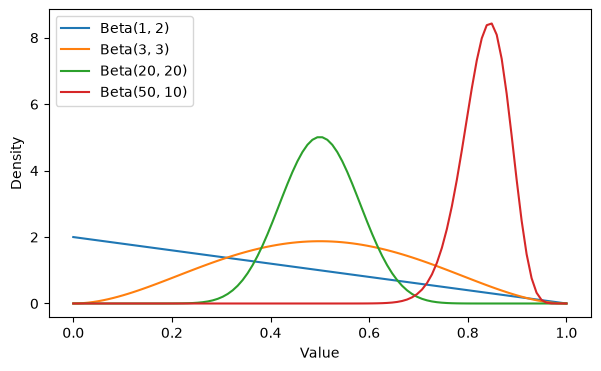

In [2]:
x = np.linspace(0, 1, 100)
betas = [(1, 2), (3, 3), (20, 20), (50, 10)]
for (a, b) in betas:
    y = stats.beta(a, b).pdf(x)
    plt.plot (x, y, label = f"Beta({a}, {b})")
# Add labels and title
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

**1.1.2 · Your turn.** For each of the four, compute the mean and standard deviation, both from the formulas above and with `stats.beta(a, b).mean()` / `.std()`. Put them in a small DataFrame.

In [3]:
info = []
for (a, b) in betas:
    beta = (a, b)
    calc_mean = (a / (a+b))
    calc_std = np.sqrt((a * b)/ (( (a + b)**2)*(a + b + 1)))
    comp_mean = stats.beta(a, b).mean()
    comp_std = stats.beta(a, b).std()
    info.append([beta, calc_mean, comp_mean, calc_std, comp_std])
df1 = pd.DataFrame(info,columns = ["Beta", "Calculated Mean", "Computed mean", "Calculated std", "Computed std"])
df1

,Beta,Calculated Mean,Computed mean,Calculated std,Computed std
0,"(1, 2)",0.3333,0.3333,0.2357,0.2357
1,"(3, 3)",0.5000,0.5000,0.1890,0.1890
2,"(20, 20)",0.5000,0.5000,0.0781,0.0781
3,"(50, 10)",0.8333,0.8333,0.0477,0.0477


**1.1.3 · Reflect.** How do $\alpha$ and $\beta$ control the *location* of the curve, and how does their *sum* control its width? Compare Beta(3, 3) with Beta(20, 20).

*1.1.3 · Your answer:*
The ratio of alpha/beta controls the center location of the beta distribution, and its sum controls the width, large values being narrower

## 2. A prior for batting averages

Before a player's first at-bat, we already know a lot: across baseball history, most season-long averages fall roughly between .210 and .350, with .270 typical. The book encodes that knowledge as Beta(81, 219).

**1.2.1 · Your turn.** Plot Beta(81, 219) over (0, 0.5). Compute its mean and the central 95% range (`.ppf([0.025, 0.975])`).

Mean:  0.27
Central 95%  [0.22134896 0.32155542]


C:\Users\XPS-13\AppData\Local\Temp\ipykernel_18948\1722859638.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


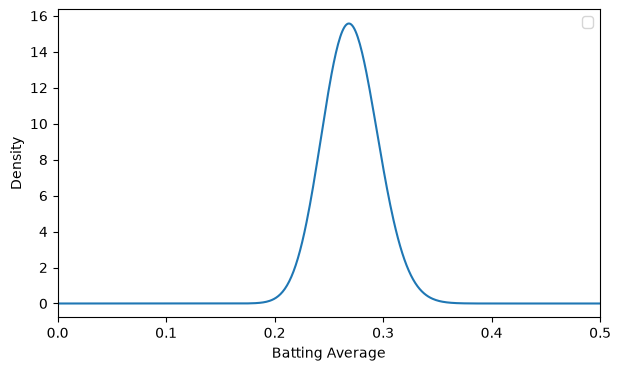

In [14]:
x = np.linspace(0, 0.5, 500)
beta2 = stats.beta(81, 219).pdf(x)
plt.xlim(0, 0.5) 
plt.plot(x, beta2)

print("Mean: ", stats.beta(81, 219).mean())
print("Central 95% ", stats.beta(81, 219).ppf([0.025, 0.975]))
plt.xlabel('Batting Average')
plt.ylabel('Density')
plt.legend()
plt.show()

> **Check:** mean ≈ 0.270; the 95% range is roughly 0.22 to 0.32.

**1.2.2 · Your turn.** Where did 81 and 219 come from? Work backwards (the *method of moments*): choose a mean $\mu = 0.27$ and a standard deviation you think fits "mostly between .21 and .35", then solve for $\alpha$ and $\beta$. Hint: with $\nu = \alpha+\beta$, the variance is $\mu(1-\mu)/(\nu+1)$.

In [5]:
mu = 0.27
sig = 0.025
var =( ((mu * (1-mu)) / (sig **2)) - 1)
alpha = mu * var
beta = var - alpha
print(alpha, beta)


84.87719999999999 229.48279999999997


## 3. Updating: prior + evidence = posterior

If the prior is Beta($\alpha_0$, $\beta_0$) and a player gets $H$ hits in $AB$ at-bats, the posterior is

$$\text{Beta}(\alpha_0 + H,\; \beta_0 + AB - H).$$

That is the whole update: add hits to $\alpha$ and misses to $\beta$.

**1.3.1 · Your turn.** On one chart, plot the prior Beta(81, 219), the posterior after 1 hit in 1 at-bat, and the posterior after 100 hits in 300 at-bats.

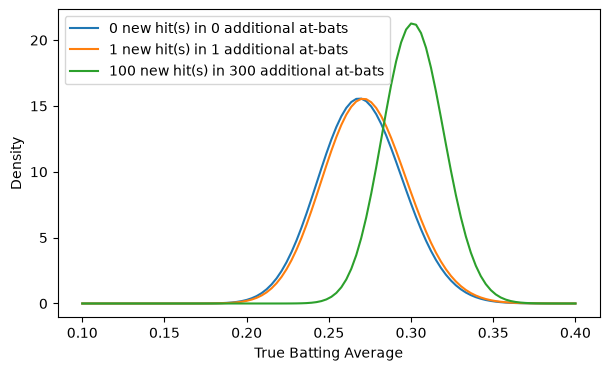

In [6]:
# 1.3.1 · Your code here
x = np.linspace(0.1, 0.4, 100)
bats = [(0,0), (1, 1), (100, 300)]

for bat in bats:
    (a, b) = bat
    hits = a
    misses = b-a
    y = stats.beta(81+hits, 219+misses).pdf(x)
    plt.plot (x, y, label = f"{a} new hit(s) in {b} additional at-bats")
# Add labels and title
plt.xlabel('True Batting Average')
plt.ylabel('Density')
plt.legend()
plt.show()

**1.3.2 · Your turn.** Compute the posterior mean after 100/300. Compare it with the raw average (100/300) and the prior mean (81/300).

In [7]:
mean100300 = (81+100) / (81 + 219 + 300)
print(mean100300, 100/300, 81/300)

0.3016666666666667 0.3333333333333333 0.27


> **Check:** the posterior mean is about 0.30: between the raw .333 and the prior .270.

**1.3.3 · Reflect.** The book describes the prior as giving every player a *head start* of hits and misses. How many at-bats' worth of head start does Beta(81, 219) give? After how many real at-bats does the player's own record carry **more weight in the estimate** than the prior does?

*Hint:* rewrite the posterior mean as a weighted average of the player's raw average and the prior mean, and ask when the player's share of the weight passes one half. We're asking how much each part *counts* toward the estimate, not whether the posterior has become statistically distinguishable from the prior; that's a different question, which Lessons 04–05 take up.

*1.3.3 · Your answer:*

A beta(81,219) gives an alpha + beta number of head start hits, in this case 300. 

## 4. Why the update works: simulating ten million players

Here's the update without any algebra. Simulate a huge population of players whose true averages come from the prior, let each bat 300 times, then keep only the ones who got exactly 100 hits. Their true averages make up the posterior.

Memory tip: 10 million draws is about 80 MB per array. Start with 1 million if your laptop complains.

**1.4.1 · Your turn.** Simulate `true_average = rng.beta(81, 219, size=N)` and `hits = rng.binomial(300, true_average)`. Keep both in a DataFrame.

In [8]:
# 1.4.1 · Your code here
N = int(1e7)
true_average = rng.beta(81, 219, size = N)
hits = rng.binomial(300, true_average)
df = pd.DataFrame({"true avg": true_average, "hits": hits})
df.head(), len(df)

(   true avg  hits
 0    0.2839    90
 1    0.2382    70
 2    0.3180    91
 3    0.3053   104
 4    0.2918    86,
 10000000)

**1.4.2 · Your turn.** Filter to players with exactly 100 hits. Plot a histogram (density scale) of their true averages, and overlay the Beta(81 + 100, 219 + 200) density.

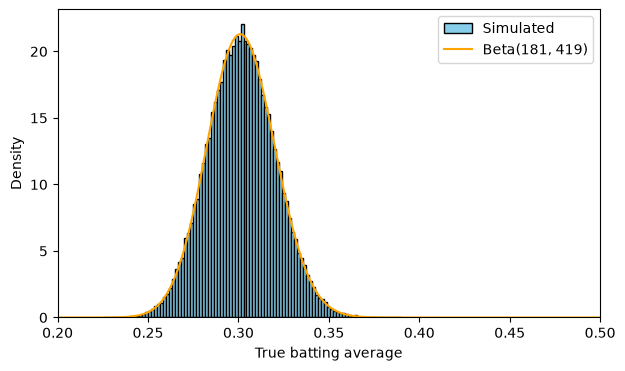

In [9]:
y_sim = df.loc[df["hits"] == 100, "true avg"]
x = np.linspace(0.2, 0.5, 500)
y_beta = stats.beta(181, 419).pdf(x)
plt.hist(y_sim, bins=100, edgecolor='black', color='skyblue', label = "Simulated", density = True)
plt.plot(x, y_beta, label = f"Beta(181, 419)", color = 'orange')
# Add labels and show plot
plt.xlabel('True batting average')
plt.xlim(0.2, 0.5) 
plt.ylabel('Density')
plt.legend()
plt.show()

> **Check:** the histogram and the curve should match closely, and the median of the filtered true averages should be about 0.30.

**1.4.3 · Your turn.** Repeat for players with 60, 80 and 100 hits, and plot the three densities together (a KDE via `stats.gaussian_kde`, or overlaid histograms).

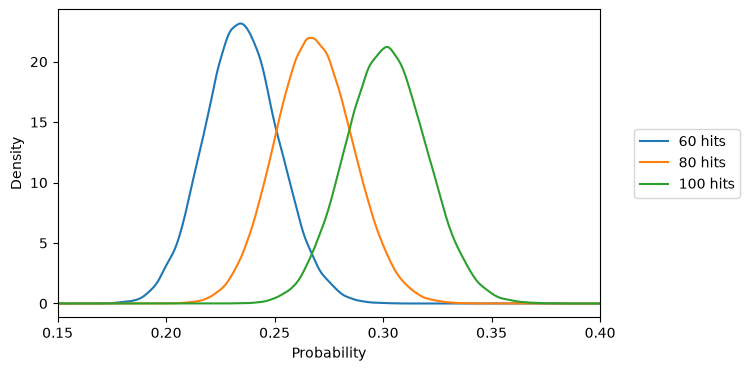

In [16]:
x = np.linspace(0.15, 0.5, 500)
y_60 = df.loc[df["hits"] == 60, "true avg"]
y_80 = df.loc[df["hits"] == 80, "true avg"]
y_100 = df.loc[df["hits"] == 100, "true avg"]
ys = [y_60, y_80, y_100]

for h in [60, 80, 100]:
    kde = stats.gaussian_kde(df.loc[df["hits"] == h, "true avg"])
    plt.plot(x, kde(x), label=f"{h} hits")
plt.xlabel('Probability')
plt.xlim(0.15, 0.4) 
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

**1.4.4 · Reflect.** In one or two sentences in your own words: what question is Bayesian updating answering when it combines a prior with evidence?

*1.4.4 · Your answer:*
In general terms, it uses the evidence to ask:
"Given that I have observed this evidence, what sample or portion of the prior distribution could have produced what I just observed?" It might be fair to say it gives a more realistic distribution *given the evidence*. I know 'realistic' would be a contentious term. It doesn't specify more likely, just more in line with observed data.

## 5. Exercises

**1.5.1 · Your turn.** A player goes 0 for 10. What's his posterior mean under the Beta(81, 219) prior? And under a much weaker prior with the same mean, Beta(8.1, 21.9)? Which prior would you trust for a major-league hitter, and why?

In [11]:
# 1.5.1 · Your code here
post_mean = 81/(81 + 229)
post_mean_weak = 8.1/(8.1 + 31.9)
print(post_mean, post_mean_weak)


0.26129032258064516 0.20249999999999999


I would trust the 'strength' of the 81, 219 prior with a simulated strength of 300 at bats than the 30 at bats with the 8.1, 22.9 prior

**1.5.2 · Your turn.** **Card connection.** Pokémon cards are sold in sealed *booster packs* of about ten randomly assorted cards. Most cards in a pack are common, but a pack occasionally contains a much rarer, more valuable card. Collectors call finding one a *hit*, and the chance that a pack contains one is its *pull rate*. One of the most sought-after kinds of hit is a *special illustration rare*, a card with full-size alternate artwork.

You open packs of a newly released set and want to estimate the chance that a pack contains a special illustration rare. From earlier sets you believe the rate is about 1 in 20 packs, but it could plausibly be anywhere from 1 in 40 to 1 in 10. (These numbers are illustrative; real pull rates vary by set and are often lower.) Pick a beta prior to match, then update it after opening 12 packs and finding 2 hits. Plot the prior and posterior.

2.588888888888889 49.18888888888889


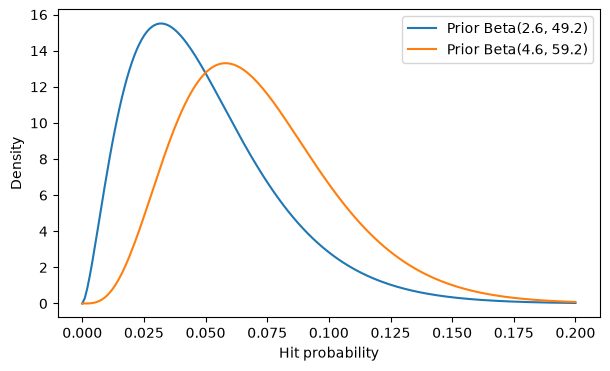

In [19]:
# 1.5.2 · Your code here

# Choose a beta distribution prior that spans between 0.025 and 0.1, centered around 0.05.
# I'll just start with a mean of about 0.06, std of 0.03
# Borrowing from 1.2.3, 
mu = 0.05
sig = 0.03
nu =( ((mu * (1-mu)) / (sig **2)) - 1)
alpha = mu * nu
beta = nu - alpha
print(alpha, beta)

#Let's use 
x = np.linspace(0, 0.2, 200)
y_prior = stats.beta(alpha, beta).pdf(x)
plt.plot(x, y_prior, label = f"Prior Beta({alpha:.1f}, {beta:.1f})")
#For 2 hits in 12 packs:
hits = 2
packs = 12
y_post = stats.beta(alpha + hits, beta + (packs - hits)).pdf(x)
plt.plot(x, y_post, label = f"Prior Beta({alpha+hits:.1f}, {beta+packs-hits:.1f})")
# Add labels and title
plt.xlabel('Hit probability')
plt.ylabel('Density')
plt.legend()
plt.show()

## References

- *Introduction to Empirical Bayes: Examples from Baseball Statistics*, David Robinson (2017), Chapter 2.
- David Robinson's original Cross Validated answer, "What is the intuition behind beta distribution?": https://stats.stackexchange.com/questions/47771
- McElreath, *Statistical Rethinking* (2nd ed.), Chapter 2: the same updating idea, done with grid approximation.